<a href="https://colab.research.google.com/github/YujieLiu666/NEON_gapfill_test/blob/main/workflow_XGB_google_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# !pip install xgboost==1.7.5

In [9]:
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# 2. Set the folder containing your script and data
site_data_dir = Path("/content/drive/MyDrive/ameriflux25_breakout")  # change if your folder is different
sys.path.append(str(site_data_dir))  # add folder to Python path
model_dir = site_data_dir / "XGB_models" # directory to save model object
model_dir.mkdir(exist_ok=True)

# 3. Import your functions
from function_XGB import *

# 4. Check current directory and files
os.chdir(site_data_dir)
print("Current directory:", os.getcwd())

Python version: 3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]
NumPy version: 2.0.2
Pandas version: 2.2.2
scikit-learn version: 1.6.1
xgboost version: 1.7.5
Matplotlib version: 3.10.0
Current directory: /content/drive/MyDrive/ameriflux25_breakout


# Input features and target variable


In [11]:
predictors = ['TIMESTAMP_END', 'GCC', 'EVI', 'Tair', 'VPD', 'PPFD']
y_col = "NEE_for_gapfill"

# Load data

- Load data from a CSV file into a `pandas.DataFrame`.
- Plot the target variable (`y_col`) over time to visualize its distribution and missing values.
- Remove rows with missing values in the target column (`y_col`) to produce a clean dataset for modeling.



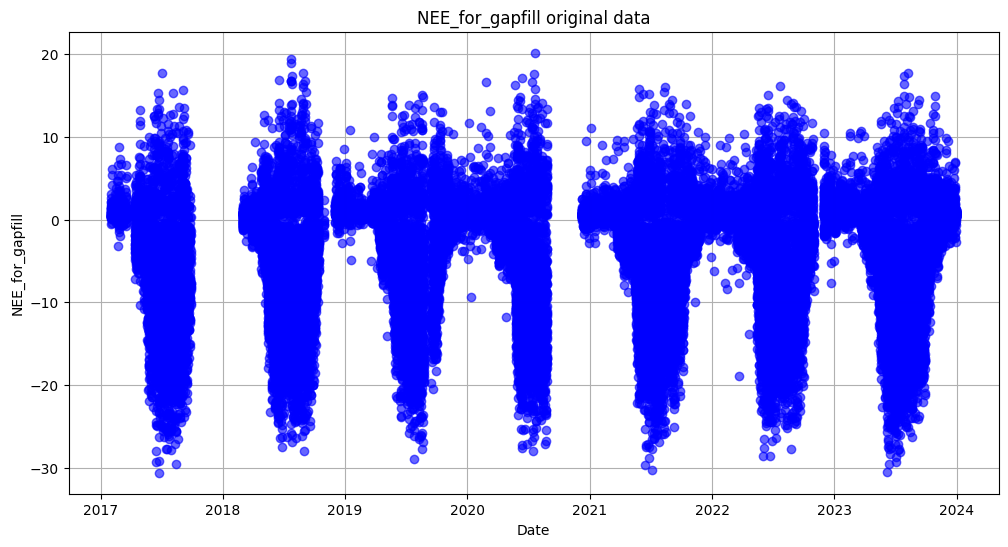

In [12]:
file_name = "data_for_XGB_BART_NEON.csv"
site_data, site_data_no_na = load_data(site_data_dir, file_name, y_col, plot=True)

# 01 Find the best hyperparameters

The `find_hyperparameters` function is designed to optimize an XGBoost regression model by performing a grid search over a predefined set of hyperparameters using 10-fold cross-validation. It returns the trained model as `.pkl` for future use.

Parameters:

- `site_data_no_na` (*DataFrame*): Cleaned data (no NA values in `y_col`).  
- `predictors` (*list of str*): Column names to be used as predictors (X).  
- `y_col` (*str*): Name of the response variable (y).  
- `model_dir` (*Path* or *str*): Directory to save the model and best parameters.  
- `n_jobs` (*int*): Number of parallel jobs for GridSearchCV.  


In [14]:
# This line takes a long time to run (> 5 hours), please keep it commented for the tutorial
# find_hyperparameters(site_data_no_na, predictors, y_col, model_dir, n_jobs = 10)

# 02 Check model performance
`check_model_performance`: Perform model evaluation with k-fold cross-validation

- Shuffle data into `k` folds (default: `n_folds = 10`)  
- Train XGBoost (or other estimator) on each fold  
- Plot learning curves for each fold  
- Compute mean and standard deviation of RMSE, R², and MAPE across folds  

**Parameters**

- `site_data` (`pandas.DataFrame`)  
  Input dataset containing predictors and target variable.

- `predictors` (`list` of `str`)  
  List of column names in `site_data` to be used as predictors (features).

- `y_col` (`str`)  
  Column name of the target variable in `site_data`.

- `reg` (`object`)  
  Regression model object with `fit`, `predict`, and `evals_result` methods  
  (e.g., `XGBRegressor`).

- `n_folds` (`int`, optional, default=10`)  
  Number of folds for cross-validation.


In [15]:
# load the model after hyperparameter tuning
model_path = model_dir / f"XGB_model_{y_col}.pkl"
reg = joblib.load(model_path)

Step 1: Shuffle & assign folds ...
Step 2: Train & evaluate for each fold ...
 Processing Fold 1...
  Train model for Fold 1...
  Plotting learning curve for Fold 1...


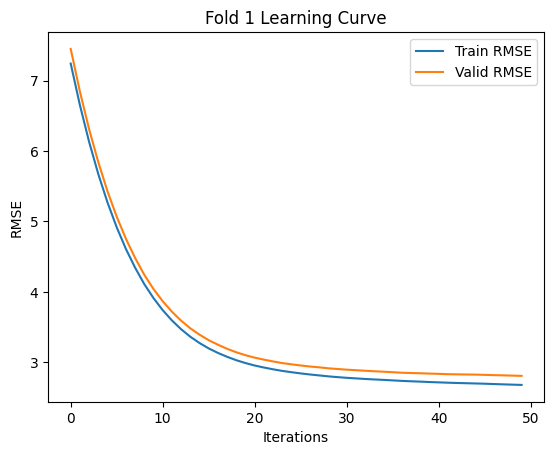

{'RMSE': np.float64(2.8072233633118318), 'R2': 0.8415311052494363, 'MAPE': np.float64(96.0019144411443)}
 Processing Fold 2...
  Train model for Fold 2...
  Plotting learning curve for Fold 2...


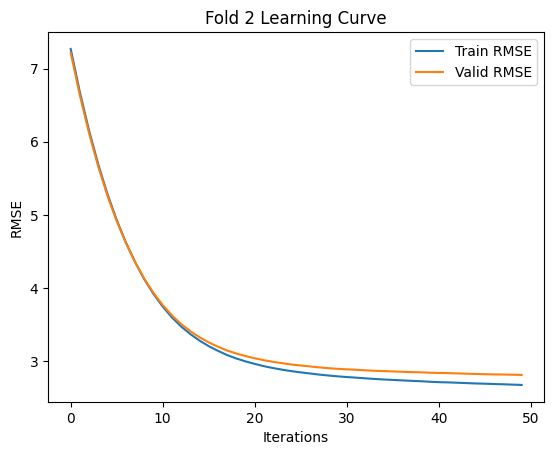

{'RMSE': np.float64(2.8123988658025287), 'R2': 0.8366349936190216, 'MAPE': np.float64(84.9154421386875)}
 Processing Fold 3...
  Train model for Fold 3...
  Plotting learning curve for Fold 3...


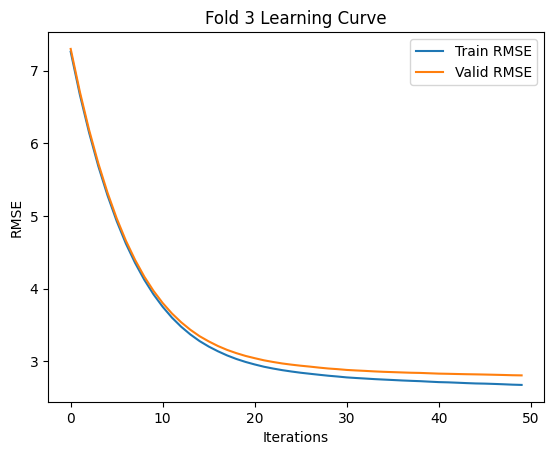

{'RMSE': np.float64(2.8064677305051466), 'R2': 0.837430281032871, 'MAPE': np.float64(80.28335563747574)}
 Processing Fold 4...
  Train model for Fold 4...
  Plotting learning curve for Fold 4...


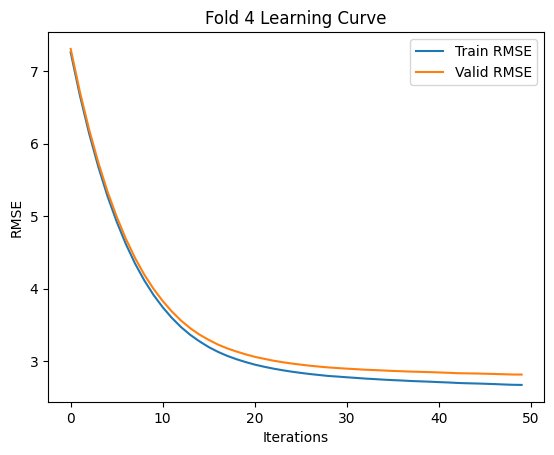

{'RMSE': np.float64(2.8165177380053037), 'R2': 0.8389802312720475, 'MAPE': np.float64(84.72129365961216)}
 Processing Fold 5...
  Train model for Fold 5...
  Plotting learning curve for Fold 5...


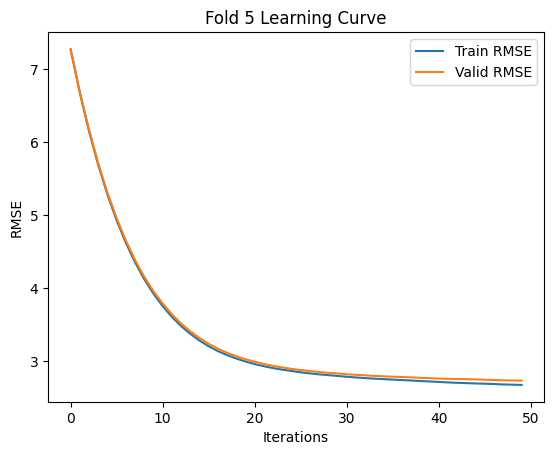

{'RMSE': np.float64(2.737915850030094), 'R2': 0.8463191219884938, 'MAPE': np.float64(83.41118284077595)}
 Processing Fold 6...
  Train model for Fold 6...
  Plotting learning curve for Fold 6...


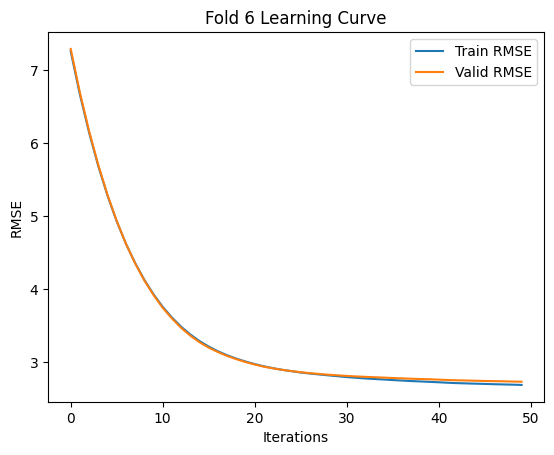

{'RMSE': np.float64(2.7279248972943586), 'R2': 0.849138096775755, 'MAPE': np.float64(84.30431724712713)}
 Processing Fold 7...
  Train model for Fold 7...
  Plotting learning curve for Fold 7...


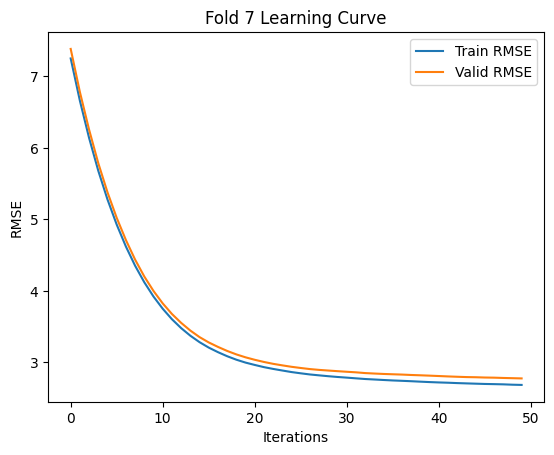

{'RMSE': np.float64(2.7745190823158965), 'R2': 0.8450666458340874, 'MAPE': np.float64(80.44348891967577)}
 Processing Fold 8...
  Train model for Fold 8...
  Plotting learning curve for Fold 8...


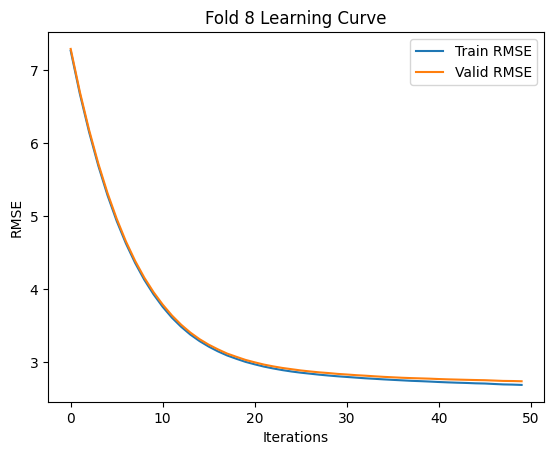

{'RMSE': np.float64(2.7344071619716197), 'R2': 0.8460766265659322, 'MAPE': np.float64(76.1032853423533)}
 Processing Fold 9...
  Train model for Fold 9...
  Plotting learning curve for Fold 9...


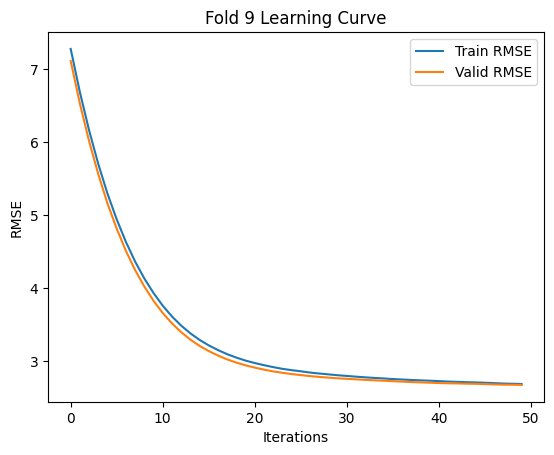

{'RMSE': np.float64(2.6729298634668814), 'R2': 0.8465346548812921, 'MAPE': np.float64(84.35742328774163)}
 Processing Fold 10...
  Train model for Fold 10...
  Plotting learning curve for Fold 10...


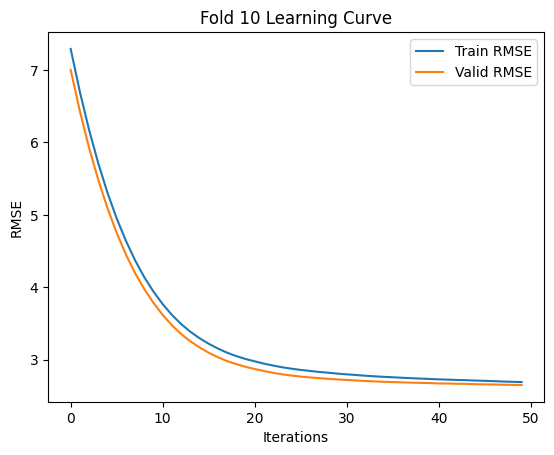

{'RMSE': np.float64(2.651353360702928), 'R2': 0.845309627137394, 'MAPE': np.float64(86.34815069452077)}
--------------------------------------------------------

Mean RMSE: 2.754 ± 0.056
Mean R²: 0.843 ± 0.004
Mean MAPE: 84.089 ± 4.901
--------------------------------------------------------


In [16]:
# check model performance
check_model_performance(site_data, predictors, y_col, reg, n_folds= 10)

# 03 Gapfill
**Parameters**

- `site_data` (`pandas.DataFrame`)  
  Full dataset (may contain missing values in `y_col`).

- `site_data_no_na` (`pandas.DataFrame`)  
  Cleaned dataset without missing values in `y_col` (used for training).

- `predictors` (`list` of `str`)  
  Column names used as predictors (X).

- `y_col` (`str`)  
  Column name of the target variable (y).

- `site_data_dir` (`pathlib.Path`)  
  Directory where output CSV will be saved.

- `reg` (`object`)  
  Regression model with `fit`/`predict` methods (e.g., `XGBRegressor`).

- `plot` (`bool`, optional, default=`False`)  
  If `True`, generate plots of observed vs. predicted values.

**Returns**

- `pandas.DataFrame`  
  Original dataframe with two new columns:
  - `XGB_FC_fall`: model predictions for all rows  
  - `XGB_FC_f`: observed values when available, otherwise filled with predictions


Predictions saved to: /content/drive/MyDrive/ameriflux25_breakout/XGB_prediction.csv


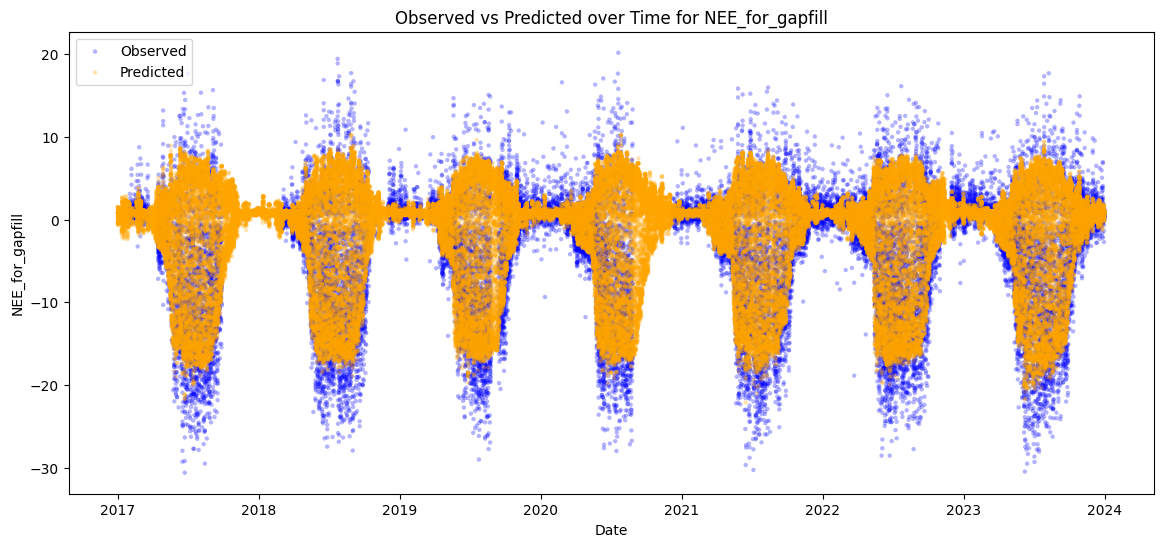

In [ ]:
df_pred_FC = get_accurate_prediction(site_data, site_data_no_na, predictors, y_col, site_data_dir, reg, plot=True)

# 04 Feature importances
**Parameters**

- `site_data_no_na` (`pandas.DataFrame`)  
  Input dataset with no missing values.

- `predictors` (`list` of `str`)  
  List of column names in `site_data_no_na` to be used as predictors (features).

- `y_col` (`str`)  
  Column name of the target variable in `site_data_no_na`.

- `site_data_dir` (`pathlib.Path`)  
  Directory where the feature importance CSV (and optionally plots) will be saved.

- `reg` (`object`)  
  Regression model with `fit`, `predict`, and `feature_importances_` attributes  
  (e.g., `XGBRegressor`).


**Returns**

- `pandas.DataFrame`  
  DataFrame containing features and their importance values, sorted in descending order.


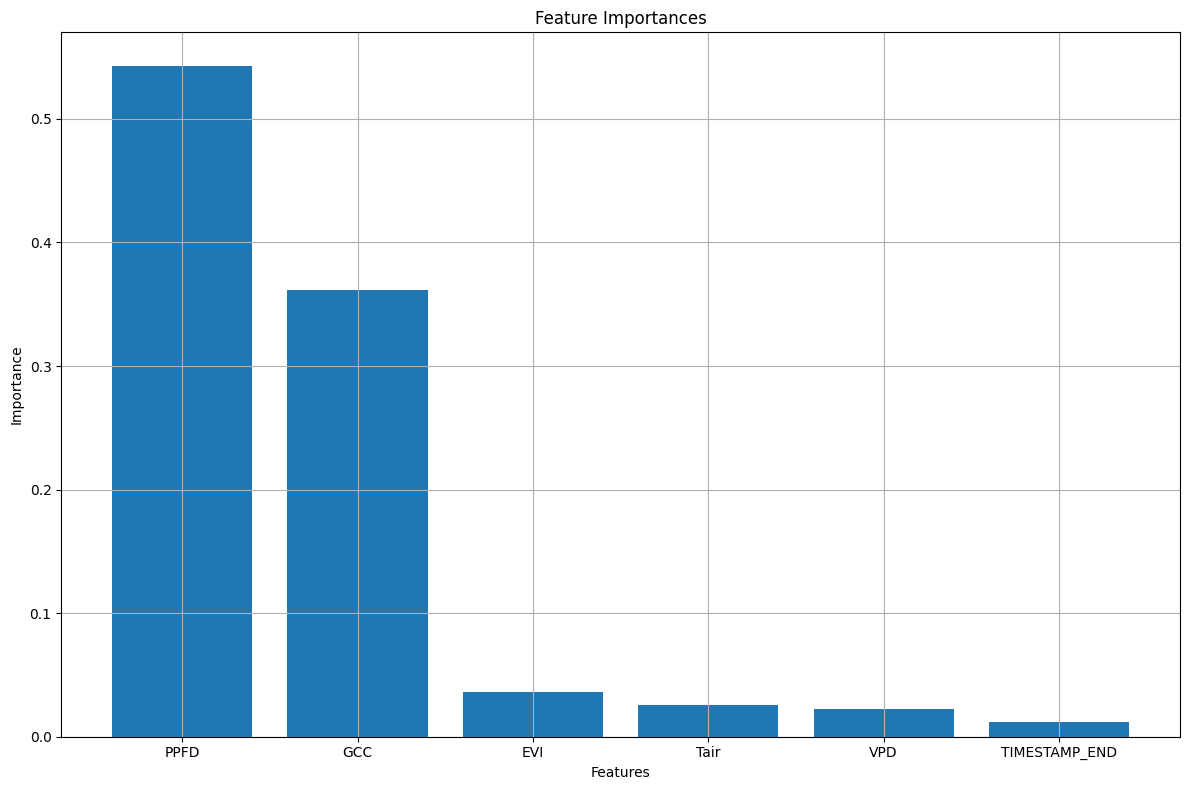

,Feature_Importances,predictors
5,0.542887,PPFD
1,0.361192,GCC
2,0.036073,EVI
3,0.025837,Tair
4,0.022268,VPD
0,0.011742,TIMESTAMP_END


In [ ]:
check_feature_importance(site_data_no_na, predictors, y_col, reg)

# 05 Compute annual sums and monthly sums

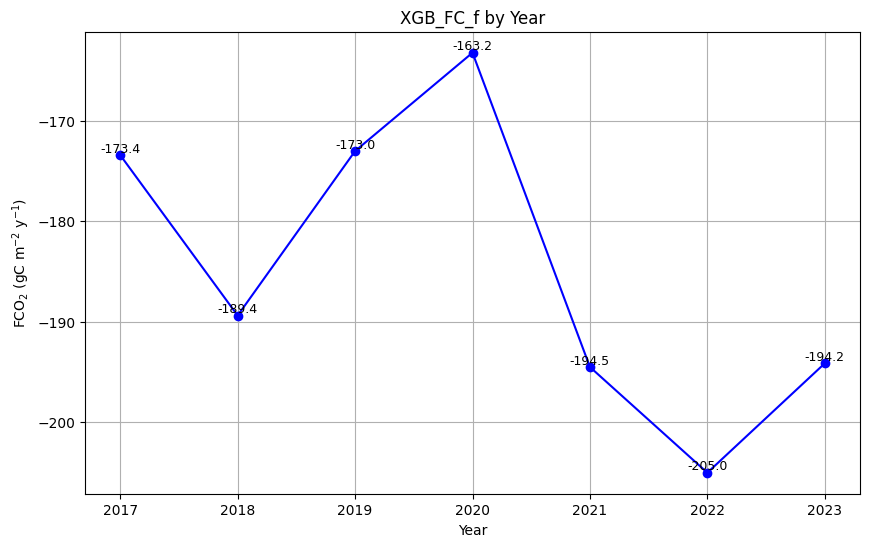

,Year,annual_sum
0,2017,-173.432357
1,2018,-189.398174
2,2019,-173.030032
3,2020,-163.244639
4,2021,-194.520744
5,2022,-205.038860
6,2023,-194.154325


In [ ]:
cal_FC_annual_sum(df_pred_FC, "XGB_FC_f", 2017, 2023, plot = True)

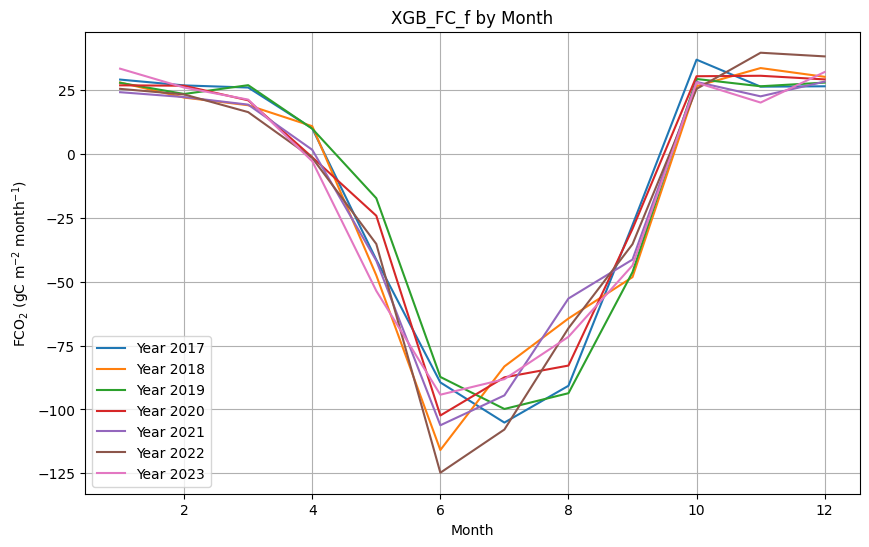

,Year,Month,monthly_sum
0,2017,1,29.042163
1,2017,2,26.762922
2,2017,3,25.932826
3,2017,4,9.930832
4,2017,5,-41.450485
...,...,...,...
79,2023,8,-71.600762
80,2023,9,-43.676442
81,2023,10,27.863257
82,2023,11,20.049091


In [ ]:
cal_FC_monthly_sum(df_pred_FC, "XGB_FC_f", 2017, 2023, plot=True)

# 06 Uncertainty in annual sums (experimental)

`get_synthetic_data`

The function generates synthetic datasets by first randomly dropping a fraction of rows to simulate missing data and then performing bootstrap sampling (sampling with replacement) to create multiple datasets that reflect the variability of the original data.

`train_on_synthetic_predict`

Train XGBoost models on bootstrap datasets and predict on original site_data.

In [ ]:
boot_datasets = get_synthetic_data(
    original_data=site_data,
    n_bootstrap=20,
    drop_fraction=0.33, # 1/3 of rows will be dropped
    sample_size= int(0.8 * len(site_data)),
    gapfill_cols= "NEE_for_gapfill",
    random_state=42
)
synthetic_predictions = train_on_synthetic_predict(site_data, boot_datasets, predictors, y_col)

In [ ]:
# List to store annual sums for each bootstrap
annual_sums_list = []

for col in synthetic_predictions.columns:
    # Create a temporary dataframe with predictions
    temp_df = site_data.copy()
    temp_df['Pred'] = synthetic_predictions[col]

    # Compute annual sums
    agg = cal_FC_annual_sum(
        data=temp_df,
        var_name='Pred',
        start_year=2017,
        end_year=2023,
        plot = False
    )

    # Keep only Year and annual_sum
    annual_sums_list.append(agg[['Year', 'annual_sum']])

# Combine all bootstraps
all_annual_sums = pd.concat(annual_sums_list, axis=1)

# The concatenation duplicates Year columns, so keep the first one and use the rest as data
years = all_annual_sums.iloc[:, 0]
annual_values = all_annual_sums.iloc[:, 1::2]  # Every second column is annual_sum

# Compute mean and std across bootstraps (synthetic datata) for each year
mean_vals = annual_values.mean(axis=1)
std_vals = annual_values.std(axis=1)

In [ ]:
# Visualise the output
# plot 1: barplot for SD of annual sums
plt.figure(figsize=(10, 6))
bars = plt.bar(years, std_vals, color='orange', alpha=0.5)

# Add SD values as text above each bar
for bar, sd in zip(bars, std_vals):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01*max(std_vals),  # slightly above the bar
             f'{sd:.0f}', ha='center', va='bottom', fontsize=10)
plt.axhline(y=25, color='red', linestyle='--', linewidth=1.5, label='y = 25')
plt.xlabel('Year')
plt.ylabel(r'FCO$_2$ (gC m$^{-2}$ y$^{-1}$)')
plt.title('SD of Annual Sums')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# plot 2: annual sums from actual gapfilling vs SD of annual sums
plt.figure(figsize=(10, 6))
# Red shaded area for annual sums from synthetic data
plt.fill_between(years, mean_vals - std_vals, mean_vals + std_vals, color='orange', alpha=0.5, label='Uncertainty')
# Plot the original XGB_FC_f predictions
annual_sum_orig = cal_FC_annual_sum(df_pred_FC, var_name='XGB_FC_f', start_year=years.min(), end_year=years.max(), plot=False)
plt.plot(annual_sum_orig['Year'], annual_sum_orig['annual_sum'], marker='o', linestyle='-', color='black', label='XGB_FC_f')
plt.xlabel('Year')
plt.ylabel(r'FCO$_2$ (gC m$^{-2}$ y$^{-1}$)')
plt.title('Uncertainty for annual sums')
plt.legend()
plt.grid(True)
plt.show()